In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [2]:
# 1. Load Dataset
df = pd.read_csv('/content/drive/MyDrive/STMIK /Coding Camp/Data/Data OCR/dataset_label.csv')

In [3]:
# 2. Pre-processing: Ambil nama kelas dari file_name
df['class'] = df['file_name'].apply(lambda x: x.split('_')[0])
df['text_length'] = df['text'].astype(str).apply(len)

In [4]:
# 3. Setup Visualisasi
sns.set(style="whitegrid")
plt.figure(figsize=(16, 10))

<Figure size 1600x1000 with 0 Axes>

<Figure size 1600x1000 with 0 Axes>

/tmp/ipykernel_1019/3740543706.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='quality', palette='magma')


Text(0, 0.5, 'Jumlah')

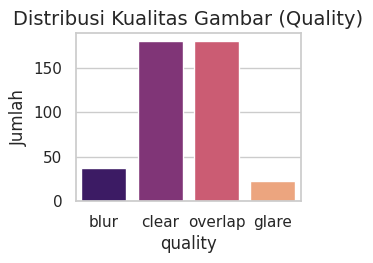

In [5]:
# --- Plot 1: Distribusi Kualitas Gambar ---
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='quality', palette='magma')
plt.title('Distribusi Kualitas Gambar (Quality)', fontsize=14)
plt.ylabel('Jumlah')

Text(0.5, 0, 'Jumlah Karakter')

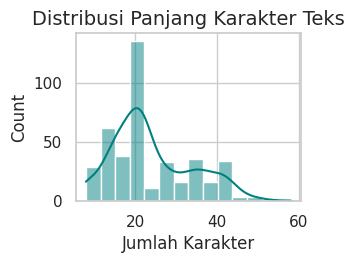

In [6]:
# --- Plot 2: Distribusi Panjang Teks (Karakter) ---
plt.subplot(2, 2, 2)
sns.histplot(df['text_length'], kde=True, color='teal')
plt.title('Distribusi Panjang Karakter Teks', fontsize=14)
plt.xlabel('Jumlah Karakter')

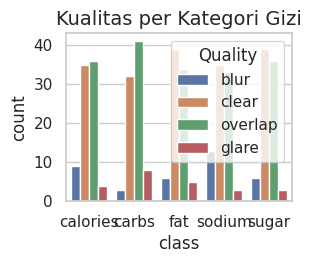

In [7]:
# --- Plot 3: Distribusi Kelas vs Kualitas ---
plt.subplot(2, 2, 3)
sns.countplot(data=df, x='class', hue='quality')
plt.title('Kualitas per Kategori Gizi', fontsize=14)
plt.legend(title='Quality', loc='upper right')

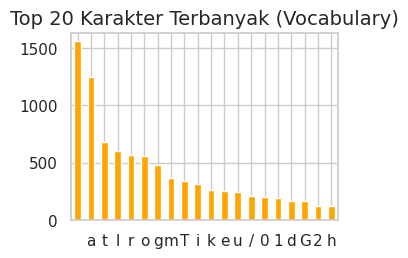

In [9]:
# --- Plot 4: Analisis Karakter Unik (Vocabulary) ---
all_text = "".join(df['text'].astype(str).tolist())
char_counts = Counter(all_text)
char_df = pd.DataFrame.from_dict(char_counts, orient='index', columns=['count']).sort_values('count', ascending=False)

plt.subplot(2, 2, 4)
char_df.head(20)['count'].plot(kind='bar', color='orange')
plt.title('Top 20 Karakter Terbanyak (Vocabulary)', fontsize=14)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [10]:
# --- Output Insight Teknis untuk AI Engineer ---
vocab = sorted(list(set(all_text)))
print("\n" + "="*40)
print("📊 RINGKASAN TEKNIS UNTUK AI ENGINEER")
print("="*40)
print(f"1. Total Vocabulary Size : {len(vocab)} karakter")
print(f"2. Daftar Karakter (Map) : {''.join(vocab)}")
print(f"3. Panjang Teks Rata-rata: {df['text_length'].mean():.1f} karakter")
print(f"4. Panjang Teks Maksimal : {df['text_length'].max()} karakter")
print(f"5. Rekomendasi :")
if 'blur' in df['quality'].values:
    print("   - Gunakan Gaussian Blur Augmentation saat training.")
if df['text_length'].max() > 50:
    print("   - Gunakan Sequence Length minimal 64 atau 128 pada model RNN.")
print("="*40)


📊 RINGKASAN TEKNIS UNTUK AI ENGINEER
1. Total Vocabulary Size : 60 karakter
2. Daftar Karakter (Map) :  %(),./0123456789:CEFGKLNSTabcdefghiklmnorstuy…化卡合水物碳糖總肪脂路里鈉
3. Panjang Teks Rata-rata: 24.0 karakter
4. Panjang Teks Maksimal : 58 karakter
5. Rekomendasi :
   - Gunakan Gaussian Blur Augmentation saat training.
   - Gunakan Sequence Length minimal 64 atau 128 pada model RNN.
